# **Tutorial 2b:** Real-Case Rock Physics Modeling

## Inspect Available logs in the LAS-file

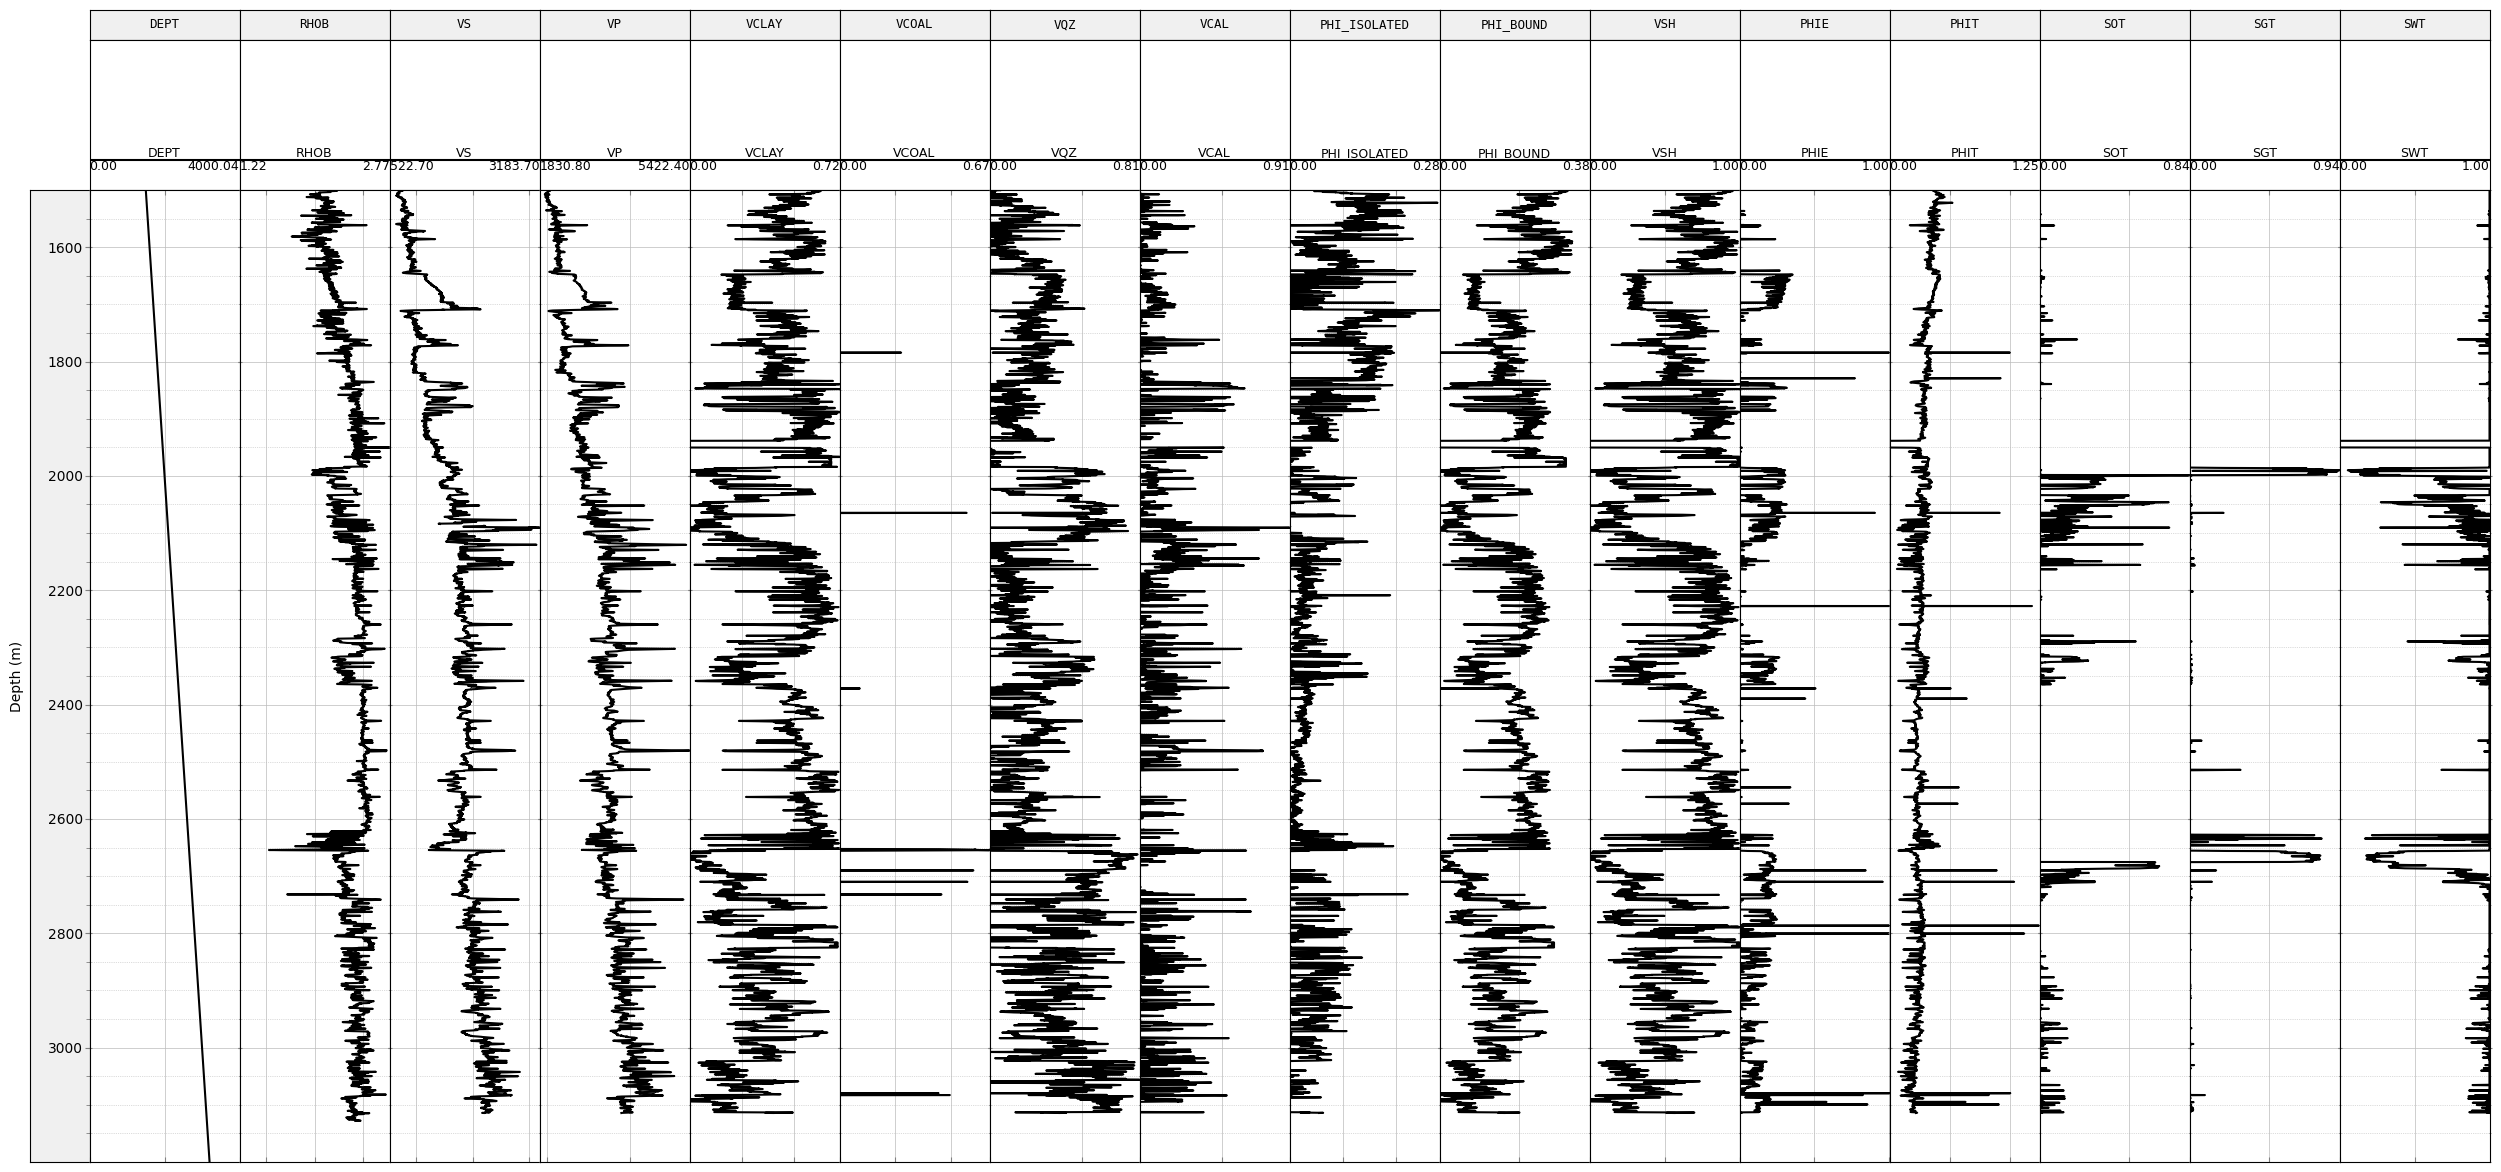

In [2]:
from rokpy.visualization import display_las
file = r".\\Well4.las"
sheet=display_las(file)
sheet.set_depth_range(1500, 3200)

## Read and Conditioning the Well-Logs

In [23]:
import lasio
from rokpy.visualization import Sheet
from rokpy.utilities import moving_median

las = lasio.read(file)
print(las.keys())

# Read and Precondition the logs from las file
depth_range = [2650, 2950]
mask = (las.depth_m>depth_range[0]) & (las.depth_m<depth_range[1])
depth = las.depth_m[mask]
window = 3
vclay   = moving_median(las.curvesdict['VCLAY'].data[mask]       ,window_size=window)
vsh     = moving_median(las.curvesdict['VSH'].data[mask]         ,window_size=window)
vqz     = moving_median(las.curvesdict['VQZ'].data[mask]         ,window_size=window)
vcal    = moving_median(las.curvesdict['VCAL'].data[mask]        ,window_size=window)
phit    = moving_median(las.curvesdict['PHIT'].data[mask]        ,window_size=window)
phibw   = moving_median(las.curvesdict['PHI_BOUND'].data[mask]   ,window_size=window)
phiiso  = moving_median(las.curvesdict['PHI_ISOLATED'].data[mask],window_size=window)
swt     = moving_median(las.curvesdict['SWT'].data[mask]         ,window_size=window)
sot     = moving_median(las.curvesdict['SOT'].data[mask]         ,window_size=window)
sgt     = moving_median(las.curvesdict['SGT'].data[mask]         ,window_size=window)
rho     = moving_median(las.curvesdict['RHOB'].data[mask]        ,window_size=window)
vp      = moving_median(las.curvesdict['VP'].data[mask]          ,window_size=window)
vs      = moving_median(las.curvesdict['VS'].data[mask]          ,window_size=window)


['DEPT', 'RHOB', 'VS', 'VP', 'VCLAY', 'VCOAL', 'VQZ', 'VCAL', 'PHI_ISOLATED', 'PHI_BOUND', 'VSH', 'PHIE', 'PHIT', 'SOT', 'SGT', 'SWT']


## Setup The Rock Model

In [29]:
from rokpy.materials import Mineral, Fluid, MineralSet, FluidSet, InclusionRock
from rokpy.effective_medium import Inclusion, InclusionMethods
from rokpy.constants import MineralsPropertyTable, FluidsPropertyTable
from rokpy.conversions import psi_to_mpa
import warnings
warnings.filterwarnings('ignore')

minerals = MineralsPropertyTable()
fluids = FluidsPropertyTable()
fluids.calculate_brine(T=40, P=psi_to_mpa(2984.), salinity=50000)
print(fluids.Brine)

clay = Mineral(minerals.DryClay)
quartz = Mineral(minerals.Quartz)
calcite = Mineral(minerals.Calcite)

brine = Fluid(fluids.Brine)
oil = Fluid(fluids.Oil)
gas = Fluid(fluids.Gas)

mineralset = MineralSet({clay:vclay, calcite:vcal, quartz:vqz}, mixing_method='voigt_reuss_hill')
fluidset = FluidSet({brine:swt, oil:1-swt})# gas:sgt

# rock = InclusionRock(mineralset, fluidset, phit, rock_frame_method = InclusionMethods.InclusionMethodName.DEM)
rock = InclusionRock(mineralset = mineralset, 
                     fluidset = fluidset, 
                     total_porosity = phit, 
                     rock_frame_method = 'dem')
rock.add_inclusion(Inclusion('SPHEROID', aspect_ratio = 0.12, content = brine), host = clay)
rock.add_inclusion(Inclusion('SPHEROID', aspect_ratio = 0.09), host = calcite)
rock.add_inclusion(Inclusion('SPHEROID', aspect_ratio = 0.2), host = quartz)


type: Brine          | rho: 1.035	| K: 2.692   | G: 0.000   | Vp: 1612.85  | Vs: 0.00     


## Optimize the Rock Model
### Estimate the Porosity Weight

[np.float64(0.2653975070155497), np.float64(0.11039089847582956), np.float64(0.2174410389835395)]


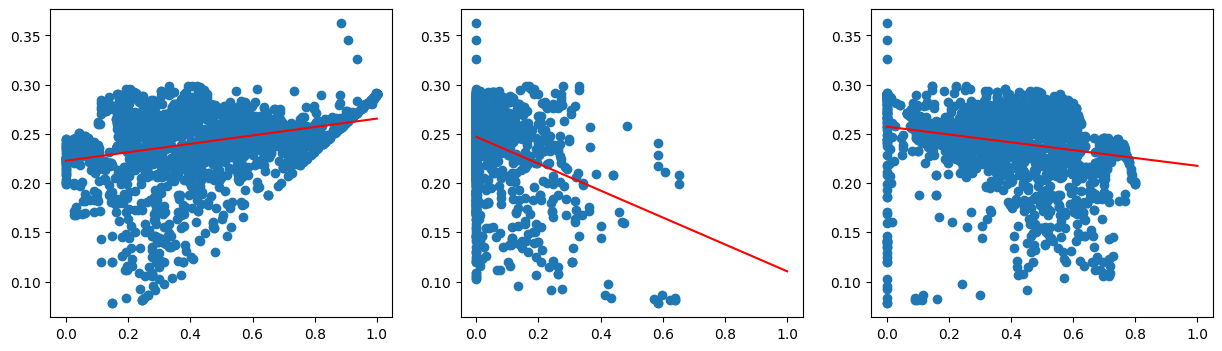

In [26]:
import matplotlib.pyplot as plt
from rokpy.models import LinearModel
from rokpy.constants import PropertyTemplates as props
import numpy as np
fig, axs = plt.subplots(1,3, figsize=(15,4))
axs[0].scatter(vsh, phit)
axs[1].scatter(vcal,phit)
axs[2].scatter(vqz, phit)

# Intecept of volume fractions of each lithology vs. total porosity at vol=1 correspond to 
# the porosity weight of that lithology
vol_vs_phit = LinearModel(x_template=props().VolumeFraction, y_template=props().Porosity)
clay.porosity_weight = np.sum(vol_vs_phit.fit_coefs(vsh, phit).coefs)
vol_vs_phit.draw(axs[0])
calcite.porosity_weight = np.sum(vol_vs_phit.fit_coefs(vcal, phit).coefs)
vol_vs_phit.draw(axs[1])
quartz.porosity_weight = np.sum(vol_vs_phit.fit_coefs(vqz, phit).coefs)
vol_vs_phit.draw(axs[2])
print(list(mineralset.porosity_weights_set().values()))

calcite.porosity_weight = 0.05


### Fine-tune the rock Parameters

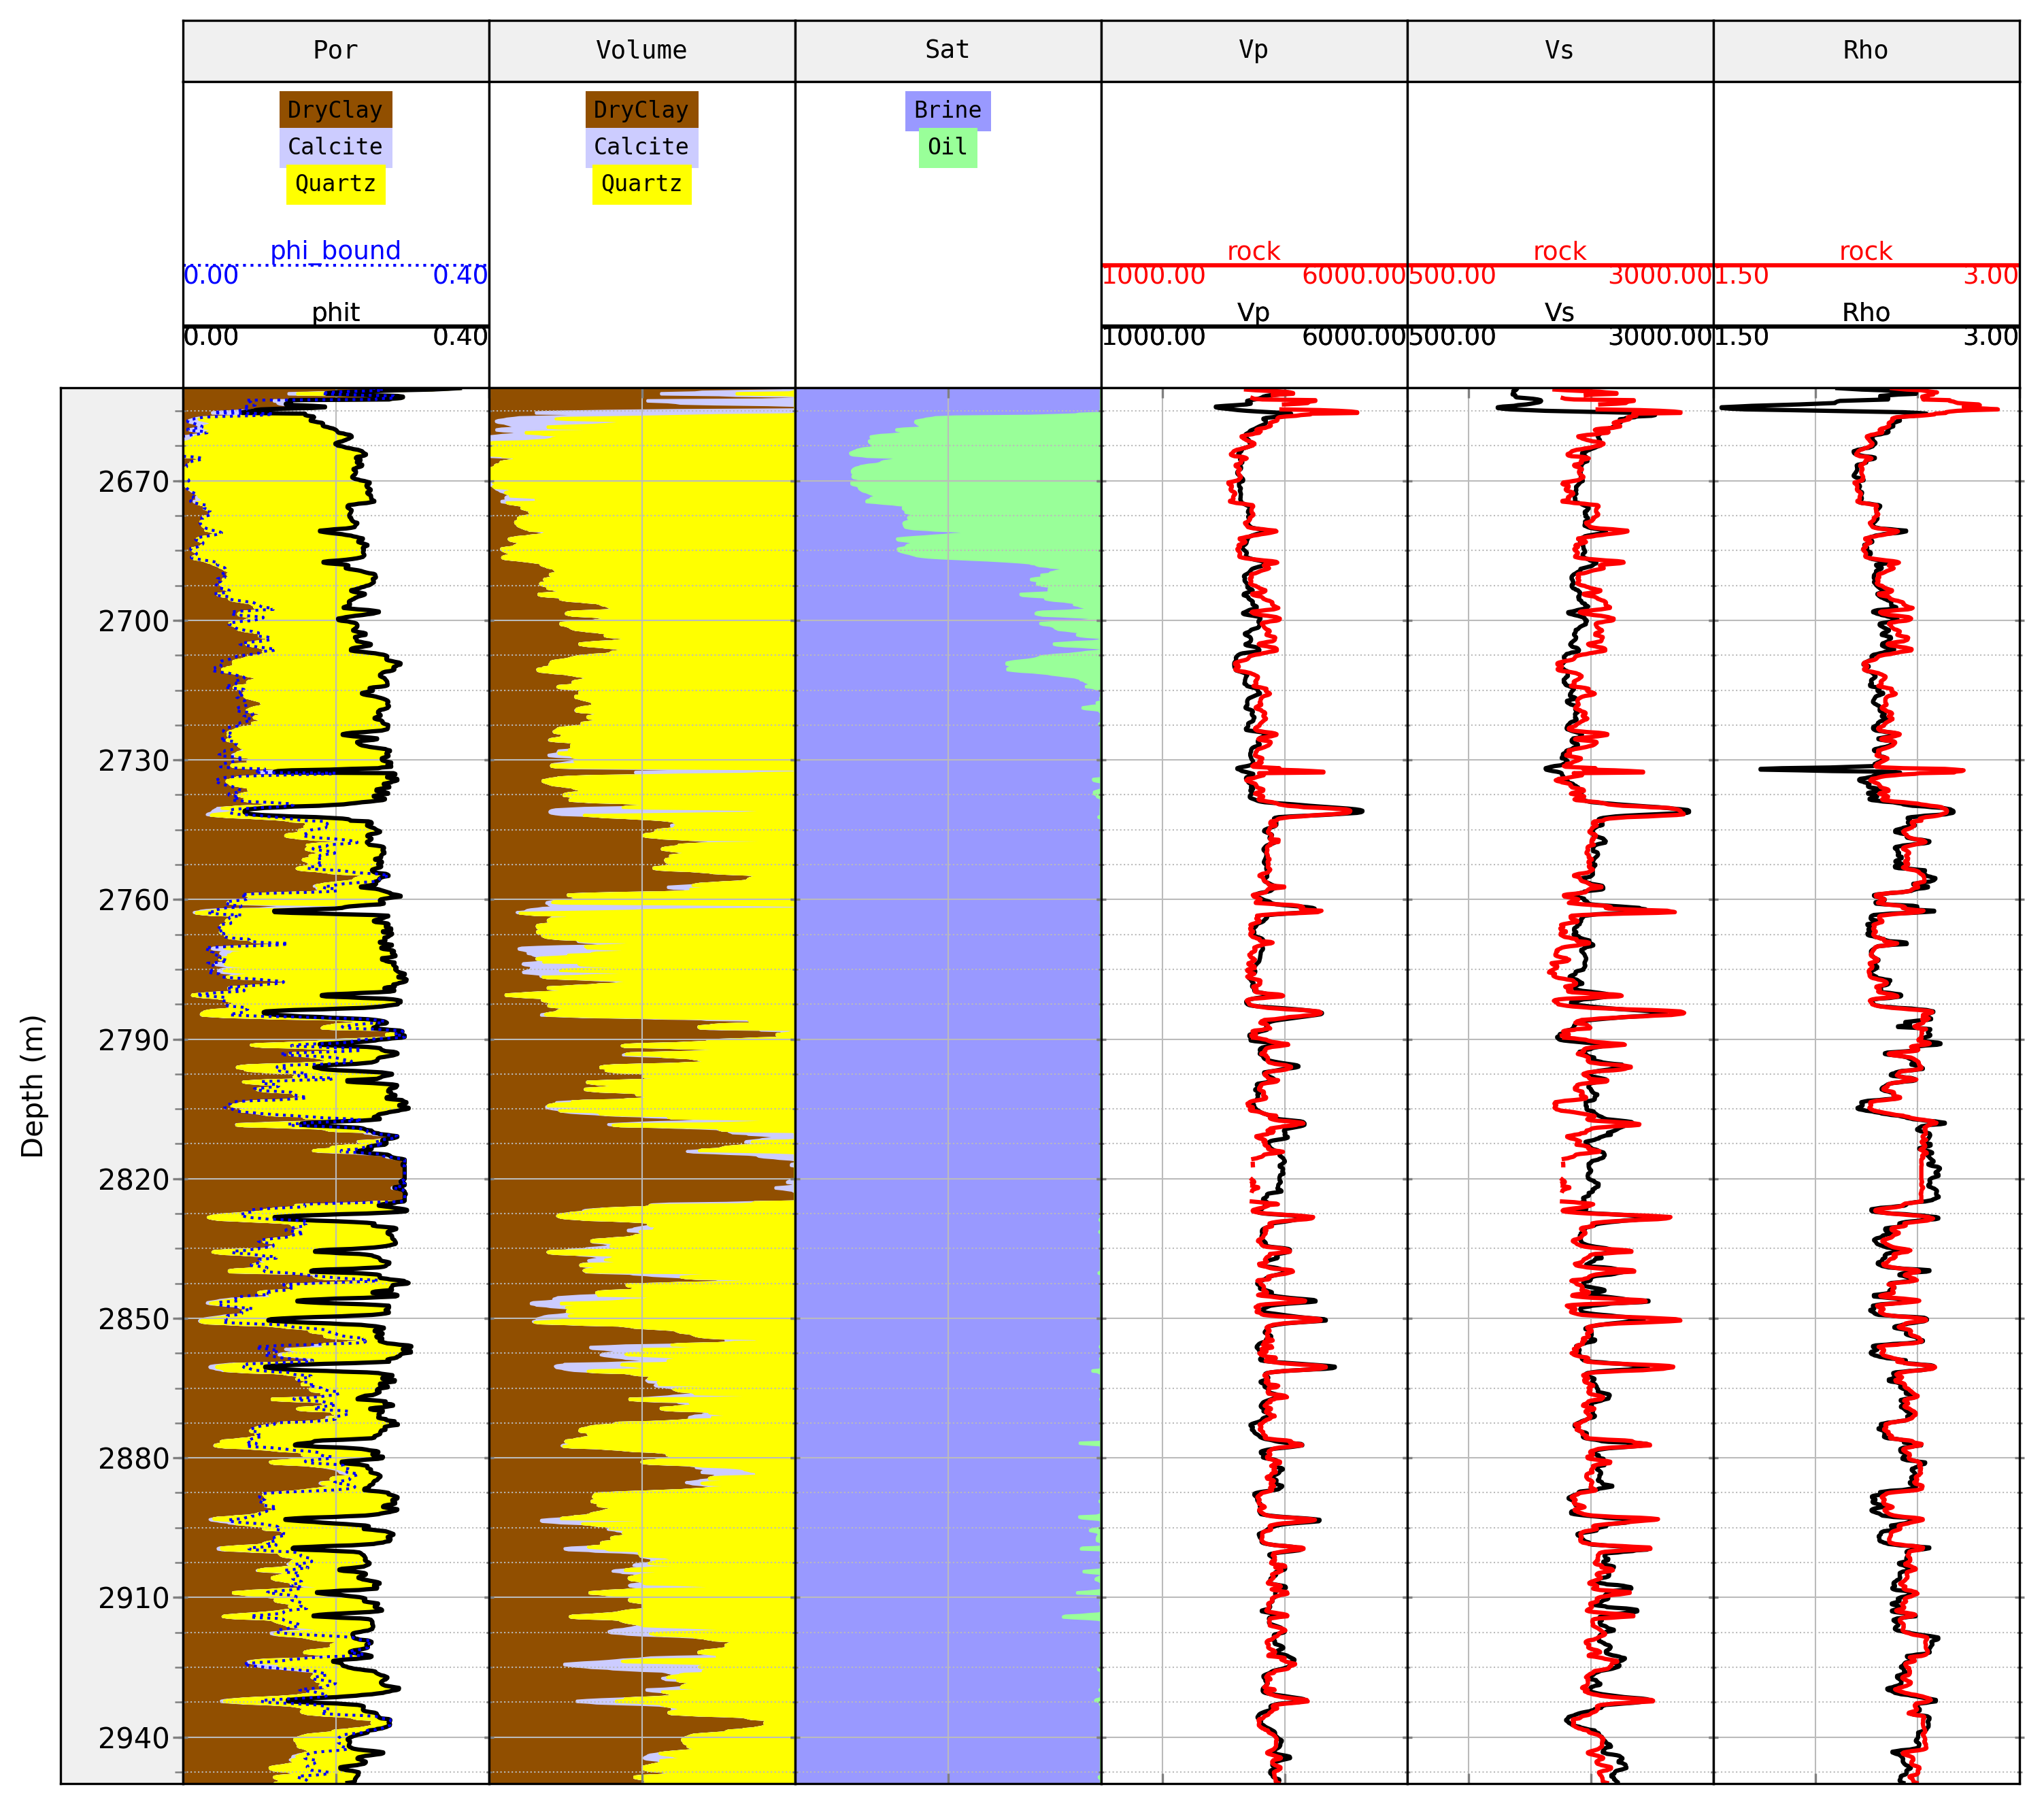

In [27]:
import matplotlib.pyplot as plt
from rokpy.constants import PropertyTemplates
sheet = plt.figure(FigureClass=Sheet, figsize=(20,9), dpi=300)
sheet.set_depth_range(*depth_range)

templates = PropertyTemplates()
templates.PVelocity.plot_range = (1000,6000)
templates.SVelocity.plot_range = (500,3000)
templates.Density.plot_range = (1.5,3)

por_tr = sheet.add_track(templates.Porosity)
vol_tr = sheet.add_track(templates.VolumeFraction)
sat_tr = sheet.add_track(templates.Saturation)
vp_tr = sheet.add_track(templates.PVelocity)
vs_tr = sheet.add_track(templates.SVelocity)
rho_tr = sheet.add_track(templates.Density)


porosity_fractionset = rock.minerals_porosity_set()
por_tr.plot(depth, phit, label='phit')
por_tr.plot_fraction_set(depth, porosity_fractionset)
por_tr.plot(depth, phibw, label='phi_bound', color='b',linewidth=1, linestyle=":")
vol_tr.plot_component_set(depth, mineralset)
sat_tr.plot_component_set(depth, fluidset)
vp_tr.plot(depth, vp)
vs_tr.plot(depth, vs)
rho_tr.plot(depth, rho)


# Tune the rock model
minerals.DryClay.set_properties(35, 15, 3.1)
minerals.Calcite.set_properties(68, 31, 2.71)
minerals.Quartz.set_properties(39.4, 43, 2.65)
fluids.Brine.set_properties(5, 0, 1.1)
fluids.Oil.set_properties(2, 0, 0.7)
fluids.Gas.set_properties(0.04, 0, 0.15)

rock.inclusions[0].aspect_ratio = 0.8  #clay 
rock.inclusions[1].aspect_ratio = 0.06  #calcite
rock.inclusions[2].aspect_ratio = 0.075 #quartz
clay.porosity_weight = 3
quartz.porosity_weight = 2
calcite.porosity_weight = 0.5


vp_tr.plot(depth, rock.p_velocity, label='rock', color='red')
vs_tr.plot(depth, rock.s_velocity, label='rock', color='red')
rho_tr.plot(depth, rock.density, label='rock', color='red')

# sheet.savefig("..\\..\\rokpy_paper\\draft\\results.eps", format="eps")

## Evaluate the Errors vs Rock Parameters 

Text(0, 0.5, 'Density Error')

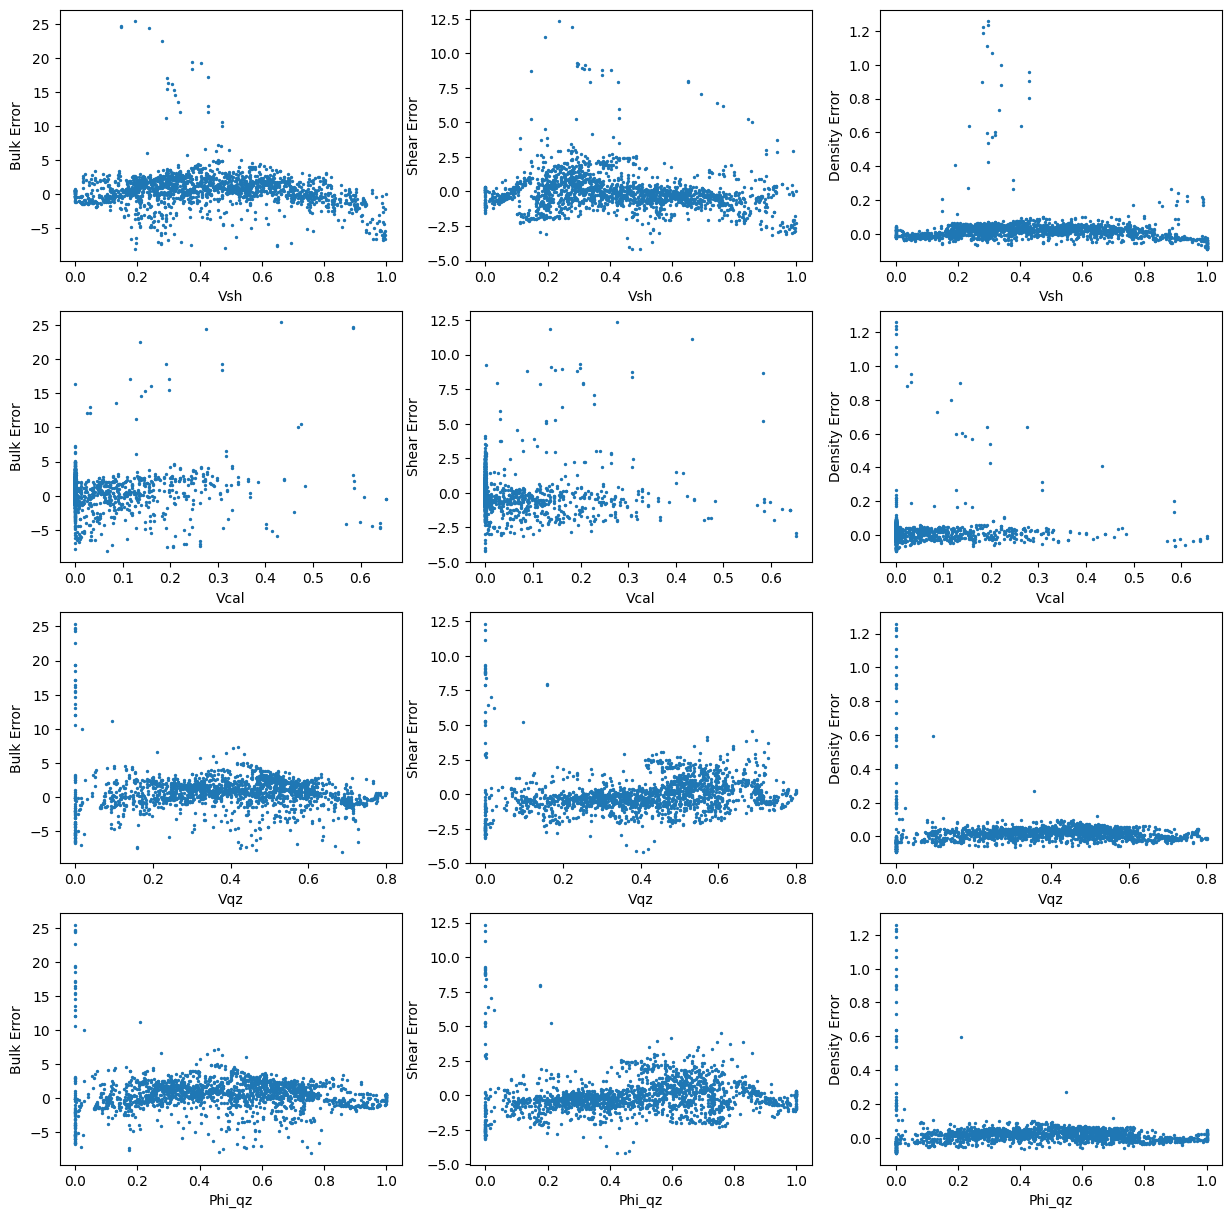

In [7]:
from matplotlib.pyplot import xlabel
from rokpy.conversions import velocity_to_modulus
fig, axs = plt.subplots(4,3, figsize=(15,15))
K, G = velocity_to_modulus(vp, vs, rho)
scale = 2
axs[0,0].scatter(vsh,  rock.bulk   - K  , s=scale)
axs[0,0].set_xlabel('Vsh')
axs[0,0].set_ylabel('Bulk Error')
axs[0,1].scatter(vsh,  rock.shear  - G  , s=scale)
axs[0,1].set_xlabel('Vsh')
axs[0,1].set_ylabel('Shear Error')
axs[0,2].scatter(vsh,  rock.density- rho, s=scale)
axs[0,2].set_xlabel('Vsh')
axs[0,2].set_ylabel('Density Error')
axs[1,0].scatter(vcal, rock.bulk   - K  , s=scale)
axs[1,0].set_xlabel('Vcal')
axs[1,0].set_ylabel('Bulk Error')
axs[1,1].scatter(vcal, rock.shear  - G  , s=scale)
axs[1,1].set_xlabel('Vcal')
axs[1,1].set_ylabel('Shear Error')
axs[1,2].scatter(vcal, rock.density- rho, s=scale)
axs[1,2].set_xlabel('Vcal')
axs[1,2].set_ylabel('Density Error')
axs[2,0].scatter(vqz,  rock.bulk   - K  , s=scale)
axs[2,0].set_xlabel('Vqz')
axs[2,0].set_ylabel('Bulk Error')
axs[2,1].scatter(vqz,  rock.shear  - G  , s=scale)
axs[2,1].set_xlabel('Vqz')
axs[2,1].set_ylabel('Shear Error')
axs[2,2].scatter(vqz,  rock.density- rho, s=scale)
axs[2,2].set_xlabel('Vqz')
axs[2,2].set_ylabel('Density Error')
axs[3,0].scatter(rock.mineralset.mineral_porosity_fraction(quartz),  rock.bulk   - K  , s=scale)
axs[3,0].set_xlabel('Phi_qz')
axs[3,0].set_ylabel('Bulk Error')
axs[3,1].scatter(rock.mineralset.mineral_porosity_fraction(quartz),  rock.shear  - G  , s=scale)
axs[3,1].set_xlabel('Phi_qz')
axs[3,1].set_ylabel('Shear Error')
axs[3,2].scatter(rock.mineralset.mineral_porosity_fraction(quartz),  rock.density- rho, s=scale)
axs[3,2].set_xlabel('Phi_qz')
axs[3,2].set_ylabel('Density Error')


## AVO Analysis

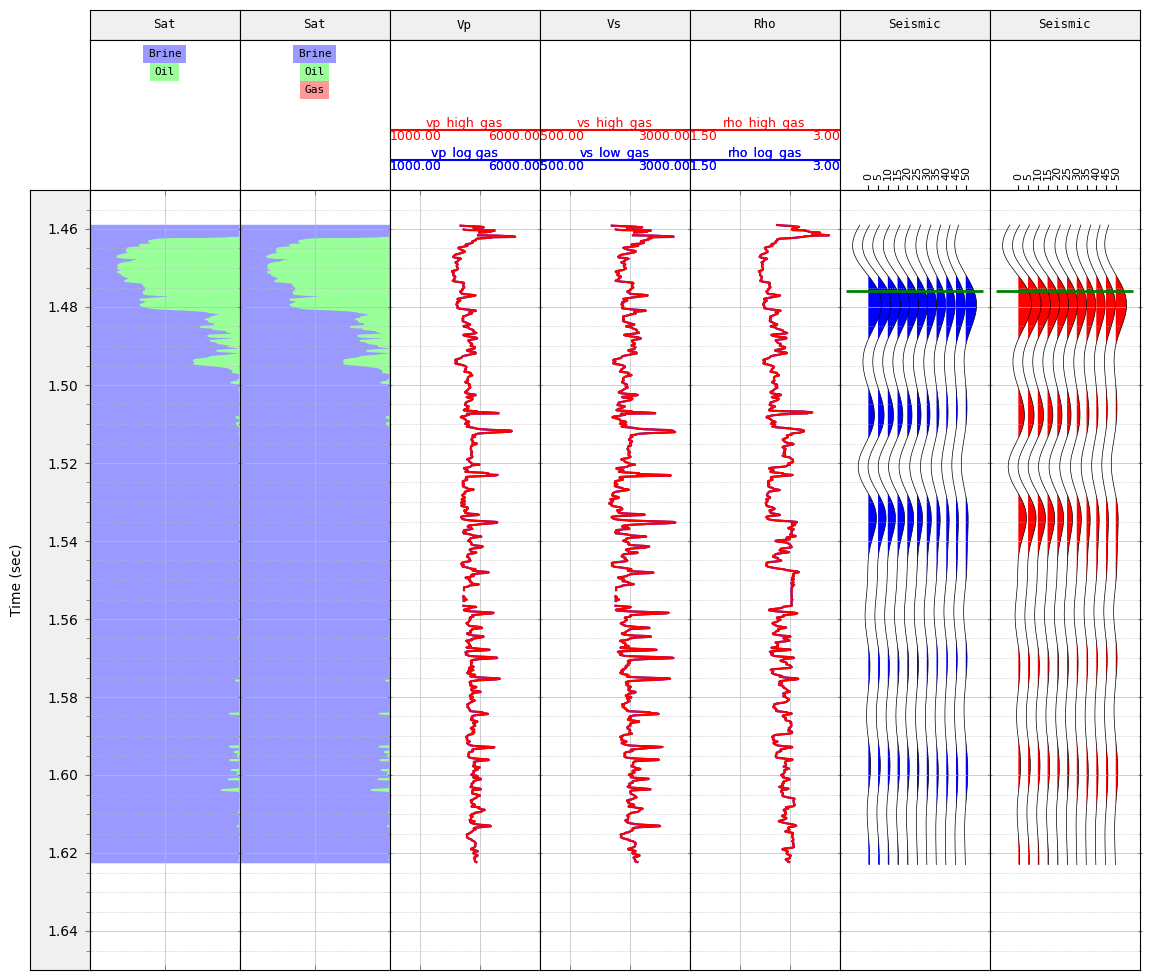

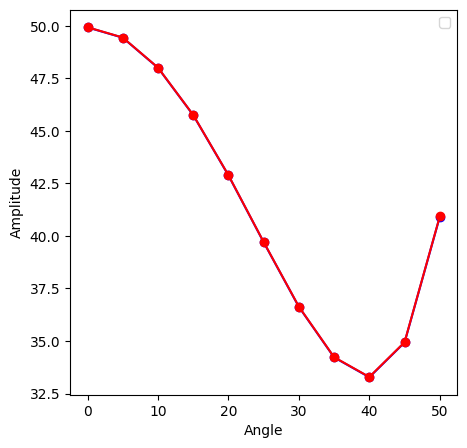

In [7]:
from copy import deepcopy
import matplotlib.pyplot as plt
from rokpy.utilities import condition_array
from rokpy.visualization import Sheet
from rokpy.avo import AVOMethods, ricker, AVOModel
import numpy as np
from rokpy.conversions import depth_to_time

# Define time sampling interval
dt = 0.001

# Define wavelet
w, _ = ricker(fdom=25, dt=dt, length=0.15)

# Make Time-Depth relation (TDR)
time_log = depth_to_time(depth, vp)
angles = np.linspace(0,50,11) #incident angles in degree

avo = AVOModel(angles, wavelet = w, dt = dt, method_name='aki_richards')

seis_insitu, rpp_insitu, time_seis = avo.seismic(rock.p_velocity, rock.s_velocity, rock.density, time_log)
rock_no_gas = deepcopy(rock)
rock_no_gas.fluidset.set_component_proportion(gas, 0*sgt)       # scenario II: Where Gas is replaced
rock_no_gas.fluidset.set_component_proportion(oil, sot+sgt)     #                             by oil
seis_no_gas, rpp_no_gas, _ = avo.seismic(rock_no_gas.p_velocity, rock_no_gas.s_velocity, rock_no_gas.density, time_log)

# Define Log Sheet
sheet = plt.figure(FigureClass=Sheet, figsize=(10, 10))
sheet.set_depth_label('Time', 'sec')
sheet.set_depth_range(1.450,1.650)  # in sec

# Add tracks to the sheet
sat_tr1 = sheet.add_track(templates.Saturation)
sat_tr2 = sheet.add_track(templates.Saturation)
vp_tr = sheet.add_track(templates.PVelocity)
vs_tr = sheet.add_track(templates.SVelocity)
ro_tr = sheet.add_track(templates.Density)
seis_tr1 = sheet.add_track(templates.Seismic)
seis_tr2 = sheet.add_track(templates.Seismic)

# # Disply each logs on the corresponding tracks
sat_tr1.plot_component_set(time_log, rock.fluidset)
sat_tr2.plot_component_set(time_log, rock_no_gas.fluidset)
vp_tr.plot(time_log, rock.p_velocity, label='vp_log gas', color='b')
vs_tr.plot(time_log, rock.s_velocity, label='vs_low_gas', color='b')
ro_tr.plot(time_log, rock.density,label='rho_log_gas', color='b')
vp_tr.plot(time_log, rock_no_gas.p_velocity, label='vp_high_gas', color='r')
vs_tr.plot(time_log, rock_no_gas.s_velocity, label='vs_high_gas', color='r')
ro_tr.plot(time_log, rock_no_gas.density,label='rho_high_gas', color='r')
seis_tr1.wiggle(seis_insitu, time_seis, angles, scale=2, color='black', fill_color='b', linewidth=0.5)
seis_tr2.wiggle(seis_no_gas, time_seis, angles, scale=2, color='black', fill_color='r', linewidth=0.5)

seis_tr1.add_marker('', time_seis[17],color='g')
seis_tr2.add_marker('', time_seis[17],color='g')

# AVO plot
goc_index = 17
fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.plot(angles, seis_insitu[goc_index,:],'-ob', angles, seis_no_gas[goc_index],'-or')
ax.set_xlabel("Angle")
ax.set_ylabel("Amplitude")
plt.legend("rpp", "seis")



